# ATLAS — Behavioral VAE
### A shared latent space for animal locomotor activity across species

This notebook trains a **β-Variational Autoencoder (β-VAE)** that maps behavioral time series from two very different animals — moon jellyfish and three-spine stickleback fish — into a single shared 8-dimensional latent space.

**Why?** No two animals move identically. Body size, recording angle, and individual variation make direct comparison hard. A shared latent representation lets us ask: *does high activity in a jellyfish look like high activity in a fish?* And can we use temperature — the common environmental driver — to anchor that comparison?

**What each species contributes:**
- **Jellyfish** (*Aurelia aurita*) — convex-hull area change rate `|d(area)/dt|` during temperature ramps (20 → 0/36/40/50 °C)
- **Stickleback** (*Gasterosteus aculeatus*, 28 dpf) — centroid speed from SLEAP pose estimates at two fixed temperatures (17 °C, 22.5 °C)

Both signals are reduced to **1 FPS** (bin-averaged from their native 30 Hz and 121 Hz), z-scored per species, and fed through species-specific Conv1d encoders into the same latent prior.

**Data:** Preprocessed arrays are included in `datasets/jellyfish_stickleback/` (generated by `scripts/preprocess_data.py`) — no raw data files required to run this notebook.

## Step 1 — Imports, constants & data

In [1]:
import numpy as np, os, sys
import torch

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

import matplotlib.pyplot as plt
from scipy.stats import percentileofscore
from atlas.train import encode_all

# ── Window lengths (samples at 1 FPS) ─────────────────────────────────────────
JELLY_WINDOW = 60   # jellyfish: 60-s window
FISH_WINDOW  = 5    # stickleback: 5-s window

# ── Dataset root ───────────────────────────────────────────────────────────────
_ROOT = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")

# ── Experiment labels (used for plotting) ──────────────────────────────────────
EXPERIMENTS = [
    {"label": "20→36°C sub-threshold crash (heating)", "cooling": False},
    {"label": "20→40°C crash (heating)",               "cooling": False},
    {"label": "20→0°C crash (cooling)",                "cooling": True},
    {"label": "20→50°C cook (heating)",                "cooling": False},
]

In [2]:
# ── Load preprocessed arrays ──────────────────────────────────────────────────
# Generated by: python scripts/preprocess_data.py  (requires raw .mat/.h5 files)
_DATASETS = os.path.join(_ROOT, 'datasets', 'jellyfish_stickleback')

_jd = np.load(os.path.join(_DATASETS, 'jellyfish.npz'), allow_pickle=True)
jelly_z       = _jd['jelly_z']
jelly_temps   = _jd['jelly_temps']
jelly_temps_z = _jd['jelly_temps_z']
jelly_labels  = _jd['jelly_labels']
j_speed_mean, j_speed_std = float(_jd['j_speed_mean']), float(_jd['j_speed_std'])
j_temp_mean,  j_temp_std  = float(_jd['j_temp_mean']),  float(_jd['j_temp_std'])

_fd = np.load(os.path.join(_DATASETS, 'fish.npz'))
fish_z        = _fd['fish_z']
fish_temps    = _fd['fish_temps']
fish_temps_z  = _fd['fish_temps_z']
f_speed_mean, f_speed_std = float(_fd['f_speed_mean']), float(_fd['f_speed_std'])
f_temp_mean,  f_temp_std  = float(_fd['f_temp_mean']),  float(_fd['f_temp_std'])

print(f'Jellyfish: {len(jelly_z)} windows  |  temp {jelly_temps.min():.1f}–{jelly_temps.max():.1f} °C')
print(f'Fish:      {len(fish_z)} windows  |  temps {list(np.unique(fish_temps))}')

Jellyfish: 2975 windows  |  temp 5.7–38.0 °C
Fish:      1854 windows  |  temps [np.float64(17.0), np.float64(22.5)]


## Step 2 — Model architecture

The VAE has three components:

| Module | Input → Output | Notes |
|--------|---------------|-------|
| `SpeciesEncoder` | `(B, T)` → `(B, 2·latent_dim)` | Three Conv1d layers + `AdaptiveAvgPool1d(4)`: works for **any T**, so jellyfish (T=60) and fish (T=5) share the same architecture with separate weights |
| `SpeciesDecoder` | `(B, latent_dim)` → `(B, T)` | MLP; output size is **species-specific** (60 for jellyfish, 5 for fish) |
| `TempHead` | `(B, latent_dim)` → `(B,)` | **Shared** across both species; regresses z-scored temperature |

**Why different window lengths are fine:** The `AdaptiveAvgPool1d(4)` layer always collapses the temporal dimension to exactly 4 time steps regardless of input length. So whether the encoder sees 60 or 5 time steps, it produces the same 512-dimensional feature vector before the FC layers. The decoder, however, must reconstruct the original length, so it is instantiated with `seq_len` matching its species.

**Reparameterization trick**: the encoder outputs `(μ, log σ²)`; during training we sample `z = μ + σ·ε` (ε ~ N(0,I)) to keep gradients flowing through the stochastic node.

**Why separate encoders, shared temperature head?** Separate encoders let each species learn its own feature detector. The shared `TempHead` creates cross-species alignment pressure: both must map equivalent behavioral states to latent regions that predict the same normalised temperature.

In [3]:
from atlas.model import BehavioralVAE

LATENT_DIM  = 8
BETA        = 4.0
LAMBDA_TEMP = 2.0

# Instantiate model — encoders handle variable T via AdaptiveAvgPool1d
model = BehavioralVAE(latent_dim=LATENT_DIM,
                      jelly_seq=JELLY_WINDOW,
                      fish_seq=FISH_WINDOW)

print(f"BehavioralVAE — jelly_window={JELLY_WINDOW}s, fish_window={FISH_WINDOW}s, "
      f"latent_dim={LATENT_DIM}, β={BETA}, λ_temp={LAMBDA_TEMP}")
print(model)


BehavioralVAE — jelly_window=60s, fish_window=5s, latent_dim=8, β=4.0, λ_temp=2.0
BehavioralVAE(
  (jelly_enc): SpeciesEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): AdaptiveAvgPool1d(output_size=4)
    )
    (fc): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=16, bias=True)
    )
  )
  (fish_enc): SpeciesEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stri

## Step 3 — Training

**Loss function:**

$$\mathcal{L} = \underbrace{\text{MSE}(x, \hat{x})}_{\text{reconstruction}} + \underbrace{\beta \cdot D_{KL}(q(z|x) \| p(z))}_{\text{KL regularisation}} + \underbrace{\lambda_{\text{temp}} \cdot \text{MSE}(\hat{T}, T)}_{\text{temperature alignment}}$$

Key choices:

- **β-VAE (β = 4.0)** — stronger KL penalty than a standard VAE; encourages disentangled, smooth latent dimensions.
- **KL annealing** — β is ramped from 0 → 4.0 linearly over the first 40 epochs. Starting with β = 0 (pure autoencoder) prevents the "posterior collapse" failure mode where the encoder ignores the input and the KL term immediately pushes everything to the prior.
- **λ_temp = 2.0** — the temperature regression loss is weighted to actively shape the latent space, not just be a side-effect.
- **Interleaved batches** — jellyfish and fish batches alternate within each epoch so both species see gradient updates in every pass.
- **NaN masking** — jellyfish temperature labels are NaN before the LED turns on; the `temp_loss` function skips these automatically.

In [4]:
from atlas.train import train, SpeedDataset

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_EPOCHS = 250
N_ANNEAL = 40    # epochs to warm up β from 0 → BETA
BATCH    = 64
LR       = 1e-3
LOG_EVERY = 25

print(f"Device: {DEVICE}  |  KL annealing over first {N_ANNEAL} epochs  "
      f"|  λ_temp={LAMBDA_TEMP}")

model = model.to(DEVICE)

history = train(
    model,
    jelly_z, jelly_temps_z,
    fish_z,  fish_temps_z,
    n_epochs=N_EPOCHS,
    n_anneal=N_ANNEAL,
    beta=BETA,
    lambda_temp=LAMBDA_TEMP,
    batch=BATCH,
    lr=LR,
    log_every=LOG_EVERY,
    device=DEVICE,
)


Device: cpu  |  KL annealing over first 40 epochs  |  λ_temp=2.0
Epoch   1/250  β=0.10  loss=5.7258  recon=1.6656  KL=0.7275  temp=1.9938
Epoch  25/250  β=2.50  loss=5.4621  recon=1.3320  KL=0.2078  temp=1.8053
Epoch  50/250  β=4.00  loss=5.5108  recon=1.5162  KL=0.1656  temp=1.6662
Epoch  75/250  β=4.00  loss=5.1153  recon=1.5523  KL=0.2072  temp=1.3672
Epoch 100/250  β=4.00  loss=4.6434  recon=1.5344  KL=0.2539  temp=1.0468
Epoch 125/250  β=4.00  loss=4.2870  recon=1.5115  KL=0.2867  temp=0.8143
Epoch 150/250  β=4.00  loss=4.0064  recon=1.5190  KL=0.2960  temp=0.6518
Epoch 175/250  β=4.00  loss=3.7984  recon=1.5094  KL=0.3022  temp=0.5402
Epoch 200/250  β=4.00  loss=3.6976  recon=1.4956  KL=0.3119  temp=0.4772
Epoch 225/250  β=4.00  loss=3.6308  recon=1.4990  KL=0.3121  temp=0.4418
Epoch 250/250  β=4.00  loss=3.5915  recon=1.5074  KL=0.3129  temp=0.4162

Training complete.


## Step 4 — Training diagnostics

Four loss curves to diagnose training health:

- **Total loss** — should decrease monotonically.
- **Reconstruction loss (MSE)** — measures how well the decoder recovers the input. A plateau suggests the VAE has found a reasonable representation.
- **KL divergence** — should start near 0 (during annealing), then rise as the model learns to use the latent space. A KL that stays near 0 after annealing indicates posterior collapse. The orange dashed line shows the β schedule for reference.
- **Temperature regression loss** — should decrease as the latent space organises around behavioral state. If this plateaus high, the temperature signal may not be strong enough to compete with the reconstruction objective (try increasing λ_temp).

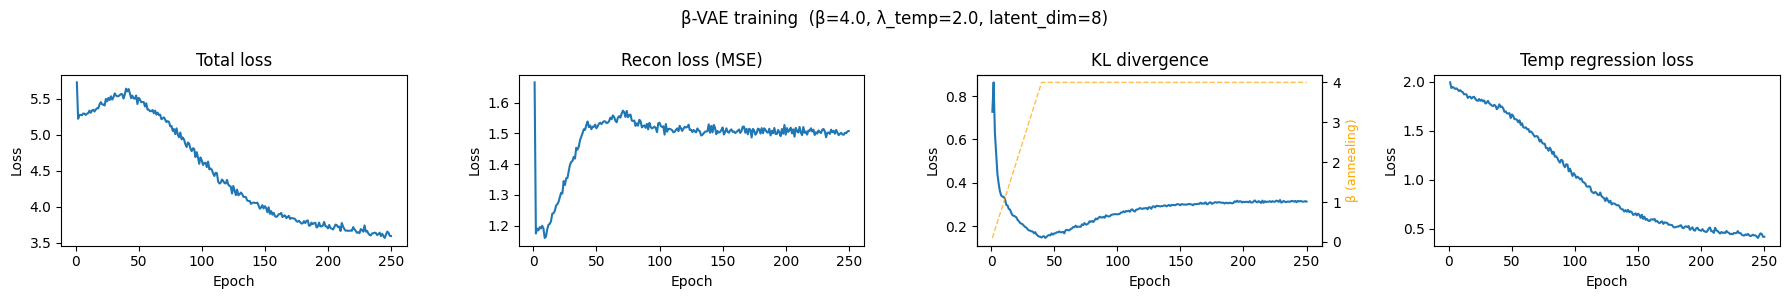

In [5]:
# ── Training loss curves ──────────────────────────────────────────────────────
hist = np.array(history)   # cols: epoch, beta, total, recon, kl, temp

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
specs = [
    (2, 'Total loss'),
    (3, 'Recon loss (MSE)'),
    (4, 'KL divergence'),
    (5, 'Temp regression loss'),
]
for ax, (col, lbl) in zip(axes, specs):
    ax.plot(hist[:, 0], hist[:, col], lw=1.5)
    if lbl == 'KL divergence':
        ax2 = ax.twinx()
        ax2.plot(hist[:, 0], hist[:, 1], lw=1, color='orange', linestyle='--', alpha=0.7)
        ax2.set_ylabel('β (annealing)', color='orange', fontsize=9)
    ax.set_title(lbl); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

plt.suptitle(f'β-VAE training  (β={BETA}, λ_temp={LAMBDA_TEMP}, latent_dim={LATENT_DIM})', fontsize=12)
plt.tight_layout()
plt.show()


## Step 5 — Encode & project to 2D (UMAP)

All windows are encoded to their posterior means `μ` (no sampling noise) and concatenated across species. A single UMAP embedding projects the full 8-D latent space to 2-D for visualisation.

In [9]:
# ── Encode all windows → latent means → UMAP ─────────────────────────────────
import umap

model.eval()

mu_j, tp_j = encode_all(model, jelly_z[:, :, 0], 'jellyfish', device=DEVICE)
mu_f, tp_f = encode_all(model, fish_z[:,  :, 0], 'fish',      device=DEVICE)
mu_all = np.vstack([mu_j, mu_f])

reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.15)
print("Fitting UMAP on latent codes …")
emb = reducer.fit_transform(mu_all)
print("Done.")

emb_j  = emb[:len(mu_j)]
emb_f  = emb[len(mu_j):]
jl_arr = np.array(jelly_labels)

pad  = 0.5
xlim = (emb[:,0].min() - pad, emb[:,0].max() + pad)
ylim = (emb[:,1].min() - pad, emb[:,1].max() + pad)

Fitting UMAP on latent codes …


/projectnb/depaqlab/bddepasq/ATLAS/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


## Step 6 — Cross-species alignment diagnostics

Five panels designed to directly test whether the shared latent space captures common behavioral structure across species.

**Panel 1 — Both species, z-scored activity**
Jellyfish (dots) and fish (triangles) on the *same* scatter, both coloured by their z-scored activity signal (blue = low, red = high). If the model learned cross-species alignment, high-activity fish and high-activity jellyfish should cluster together — and low-activity animals of both species should occupy the same region.

**Panel 2 — Both species, within-species thermal percentile**
Removes the absolute temperature difference between species (17–22.5 °C fish vs. 20–38 °C jellyfish) by normalising each species to 0 (coldest) → 1 (warmest) within its own range. If the latent space captures thermal state, jellyfish and fish at similar thermal percentiles should cluster — regardless of what °C those states correspond to.

**Panel 3 — Jellyfish by experiment**
Reference panel: which experiment does each jellyfish window belong to? Useful context for interpreting panels 1 and 2.

**Panel 4 — Predicted vs actual temperature (°C)**
The shared TempHead predicts temperature from z; un-z-scored back to °C. Points near the diagonal mean the latent code genuinely encodes temperature-linked state for both species. Systematic bias (fish always predicted too high/low) suggests the temperature scales didn't align across species.


**Panel 5 — Fish overlaid on jellyfish experiments**
Fish windows (triangles) plotted on top of jellyfish experiment clusters. Which behavioral regime do fish at 17 °C vs 22.5 °C land near? Overlap with a particular jellyfish experiment is the strongest cross-species alignment signal.

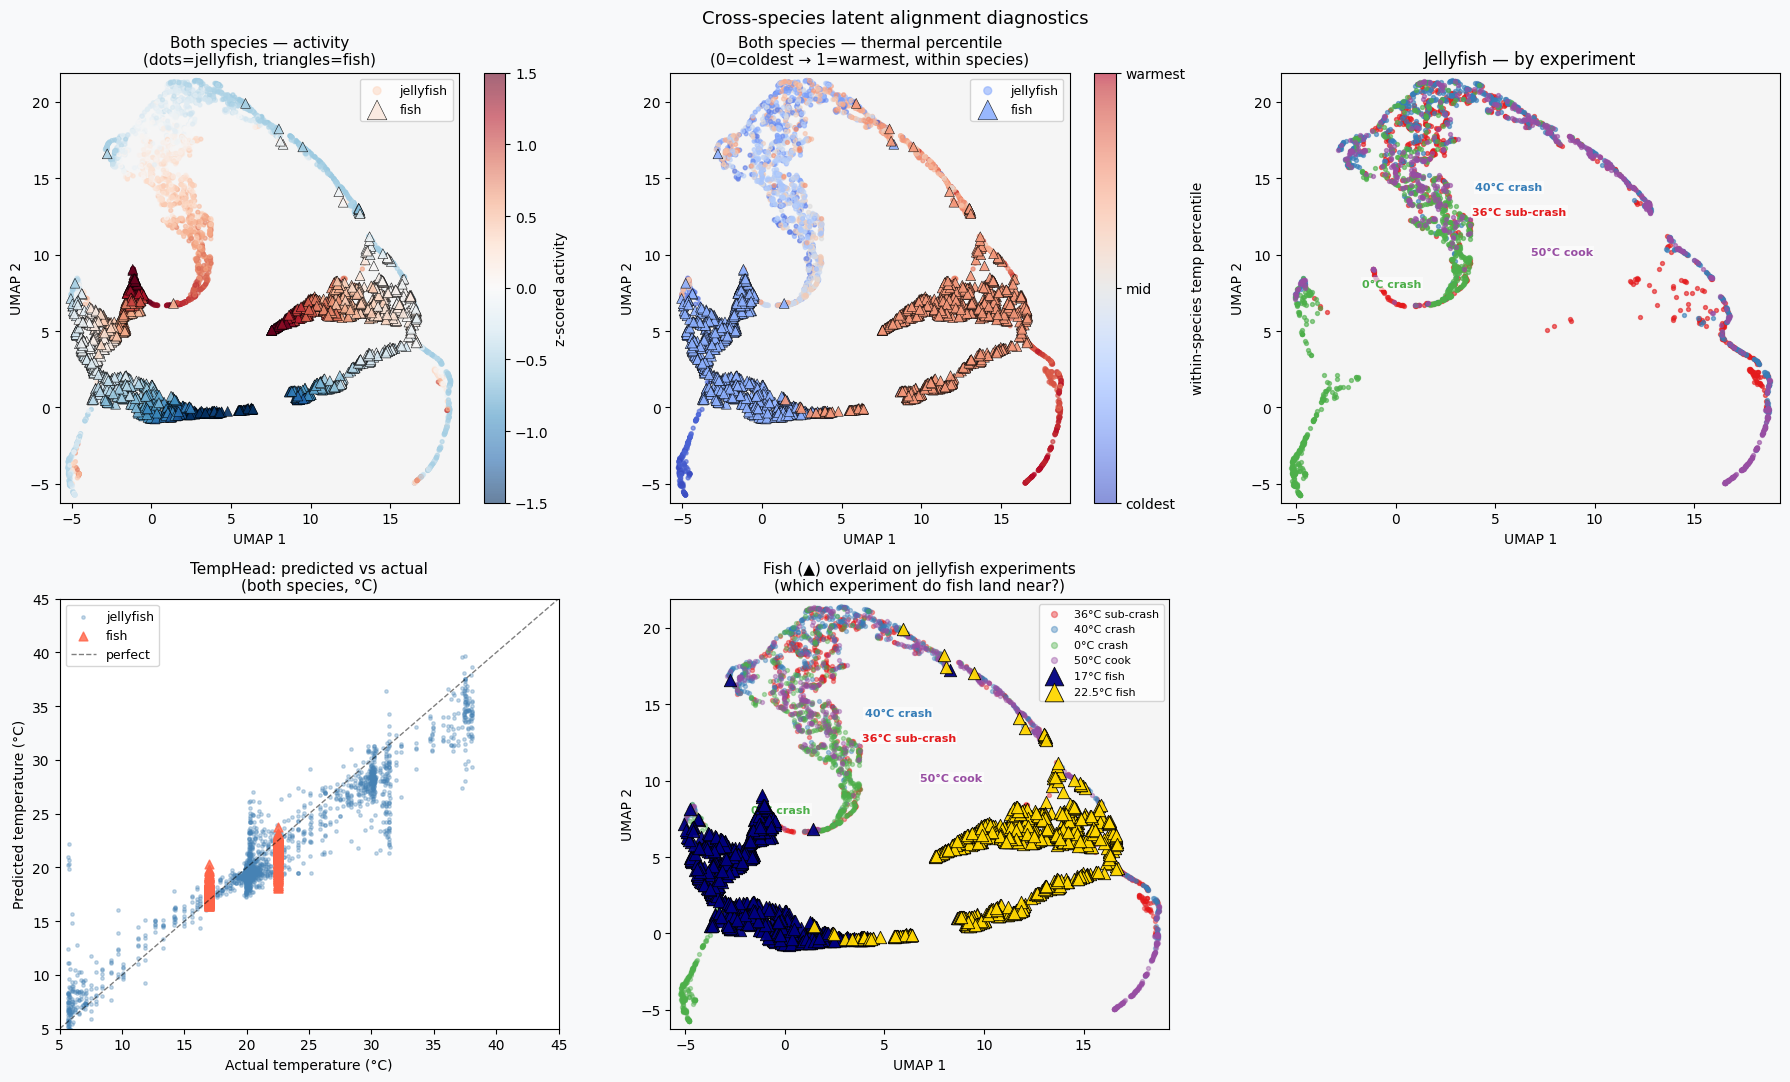

Saved → latent_diagnostics.png


In [10]:
# ── Diagnostic plots: cross-species alignment ────────────────────────────────
from scipy.stats import percentileofscore

model.eval()

mu_j, tp_j = encode_all(model, jelly_z[:, :, 0], 'jellyfish', device=DEVICE)
mu_f, tp_f = encode_all(model, fish_z[:,  :, 0], 'fish',      device=DEVICE)
mu_all     = np.vstack([mu_j, mu_f])

# UMAP on the joint latent space (reuse if already computed)
try:
    emb
except NameError:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.15)
    emb     = reducer.fit_transform(mu_all)

emb_j = emb[:len(mu_j)]
emb_f = emb[len(mu_j):]

# Shared axis limits
pad  = 0.5
xlim = (emb[:,0].min() - pad, emb[:,0].max() + pad)
ylim = (emb[:,1].min() - pad, emb[:,1].max() + pad)

# Activity (z-scored input signal mean per window)
act_j = jelly_z[:, :, 0].mean(axis=1)
act_f = fish_z[:,  :, 0].mean(axis=1)
act_vmin, act_vmax = -1.5, 1.5

# Within-species temperature percentile (0=coldest, 1=warmest for each species)
def temp_pctile(temps):
    return np.array([percentileofscore(temps, t, kind='rank') / 100 for t in temps])

pctile_j = temp_pctile(jelly_temps)
pctile_f = temp_pctile(fish_temps)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
axes[5].set_visible(False)  # hide unused 6th panel
fig.patch.set_facecolor('#f8f9fa')

# ── 1. Both species — z-scored activity ───────────────────────────────────────
# Direct test: do high-activity jellyfish and high-activity fish cluster together?
ax = axes[0]
ax.set_facecolor('#f5f5f5')
sc = ax.scatter(emb_j[:,0], emb_j[:,1], c=act_j, cmap='RdBu_r',
                vmin=act_vmin, vmax=act_vmax, s=8, alpha=0.6,
                marker='o', label='jellyfish')
ax.scatter(emb_f[:,0], emb_f[:,1], c=act_f, cmap='RdBu_r',
           vmin=act_vmin, vmax=act_vmax, s=50, alpha=0.9,
           marker='^', edgecolors='k', linewidths=0.4, label='fish')
plt.colorbar(sc, ax=ax, label='z-scored activity')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(markerscale=2, fontsize=9)
ax.set_title('Both species — activity\n(dots=jellyfish, triangles=fish)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 2. Both species — within-species temperature percentile ───────────────────
# Removes absolute temperature difference. 0=coldest, 1=warmest within each species.
# Cross-species alignment: do jellyfish and fish at similar thermal percentiles cluster?
ax = axes[1]
ax.set_facecolor('#f5f5f5')
sc2 = ax.scatter(emb_j[:,0], emb_j[:,1], c=pctile_j, cmap='coolwarm',
                 vmin=0, vmax=1, s=8, alpha=0.6,
                 marker='o', label='jellyfish')
ax.scatter(emb_f[:,0], emb_f[:,1], c=pctile_f, cmap='coolwarm',
           vmin=0, vmax=1, s=50, alpha=0.9,
           marker='^', edgecolors='k', linewidths=0.4, label='fish')
cb = plt.colorbar(sc2, ax=ax, label='within-species temp percentile')
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(['coldest', 'mid', 'warmest'])
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(markerscale=2, fontsize=9)
ax.set_title('Both species — thermal percentile\n(0=coldest → 1=warmest, within species)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 3. Jellyfish by experiment ────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#f5f5f5')
exp_colors  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
short_labels = ['36°C sub-crash', '40°C crash', '0°C crash', '50°C cook']
jl_arr = np.array(jelly_labels)
for ei, exp in enumerate(EXPERIMENTS):
    m   = jl_arr == exp['label']
    pts = emb_j[m]
    ax.scatter(pts[:,0], pts[:,1], color=exp_colors[ei], s=8, alpha=0.6,
               label=short_labels[ei])
    cx, cy = pts[:,0].mean(), pts[:,1].mean()
    ax.text(cx, cy, short_labels[ei], fontsize=8, color=exp_colors[ei],
            ha='center', va='center', fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Jellyfish — by experiment', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 4. Predicted vs actual temperature ────────────────────────────────────────
ax = axes[3]
tp_j_c = tp_j * j_temp_std + j_temp_mean
tp_f_c = tp_f * f_temp_std + f_temp_mean

valid_j = ~np.isnan(jelly_temps)
ax.scatter(jelly_temps[valid_j], tp_j_c[valid_j],
           c='steelblue', s=6, alpha=0.3, label='jellyfish')
ax.scatter(fish_temps, tp_f_c,
           c='tomato', s=40, marker='^', alpha=0.8, label='fish')
lim = [5, 45]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='perfect')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual temperature (°C)')
ax.set_ylabel('Predicted temperature (°C)')
ax.set_title('TempHead: predicted vs actual\n(both species, °C)', fontsize=11)
ax.legend(fontsize=9)


# ── 5. Jellyfish experiments + fish temperature groups ────────────────────────
# Which jellyfish experiments do the fish land near?
ax = axes[4]
ax.set_facecolor('#f5f5f5')
jl_arr = np.array(jelly_labels)
for ei, exp in enumerate(EXPERIMENTS):
    m   = jl_arr == exp['label']
    pts = emb_j[m]
    ax.scatter(pts[:,0], pts[:,1], color=exp_colors[ei], s=8, alpha=0.4,
               label=short_labels[ei])
    cx, cy = pts[:,0].mean(), pts[:,1].mean()
    ax.text(cx, cy, short_labels[ei], fontsize=8, color=exp_colors[ei],
            ha='center', va='center', fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

fish_groups = {17.0: ('navy', '17°C fish'), 22.5: ('gold', '22.5°C fish')}
for temp_val, (col, lbl) in fish_groups.items():
    m = np.isclose(fish_temps, temp_val)
    ax.scatter(emb_f[m,0], emb_f[m,1], color=col, s=80, alpha=0.95,
               marker='^', edgecolors='k', linewidths=0.6, label=lbl, zorder=5)

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Fish (▲) overlaid on jellyfish experiments\n(which experiment do fish land near?)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=8, markerscale=1.5)

fig.suptitle('Cross-species latent alignment diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('latent_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → latent_diagnostics.png")


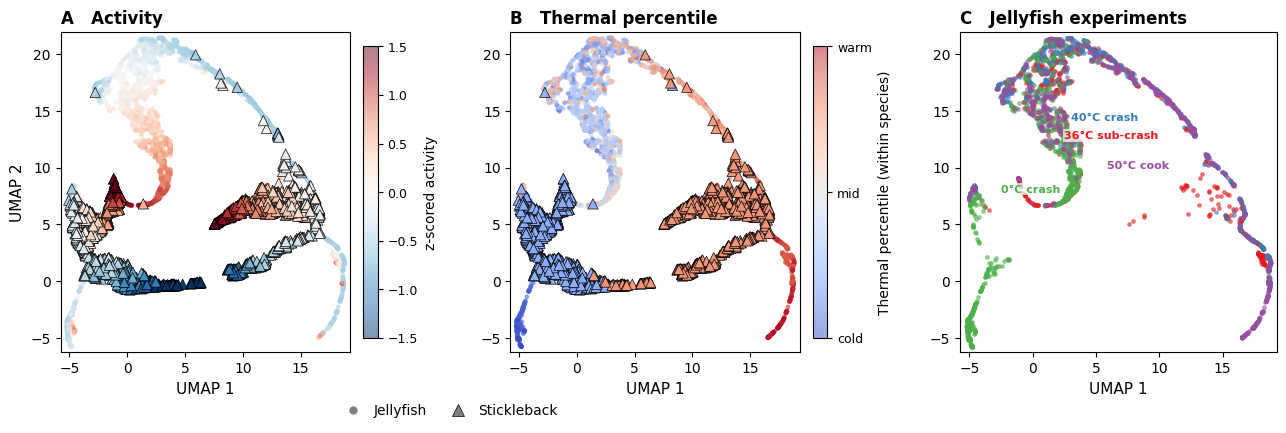

Saved → latent_alignment_figure.pdf / .png


In [8]:
# ── Camera-ready figure: panels 1–3 ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Publication style
mpl.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'axes.linewidth':   0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
})

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# ── Panel A — z-scored activity ───────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(emb_j[:,0], emb_j[:,1], c=act_j, cmap='RdBu_r',
                vmin=-1.5, vmax=1.5, s=6, alpha=0.5, marker='o', rasterized=True)
ax.scatter(emb_f[:,0], emb_f[:,1], c=act_f, cmap='RdBu_r',
           vmin=-1.5, vmax=1.5, s=55, alpha=0.95,
           marker='^', edgecolors='k', linewidths=0.5, zorder=5, rasterized=True)
cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('z-scored activity', fontsize=10)
cb.ax.tick_params(labelsize=9)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('A   Activity', loc='left', fontweight='bold')
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, label='Jellyfish'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='grey',
           markeredgecolor='k', markeredgewidth=0.5, markersize=9, label='Stickleback'),
]

# ── Panel B — within-species thermal percentile ───────────────────────────────
ax = axes[1]
sc2 = ax.scatter(emb_j[:,0], emb_j[:,1], c=pctile_j, cmap='coolwarm',
                 vmin=0, vmax=1, s=6, alpha=0.5, marker='o', rasterized=True)
ax.scatter(emb_f[:,0], emb_f[:,1], c=pctile_f, cmap='coolwarm',
           vmin=0, vmax=1, s=55, alpha=0.95,
           marker='^', edgecolors='k', linewidths=0.5, zorder=5, rasterized=True)
cb2 = plt.colorbar(sc2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label('Thermal percentile (within species)', fontsize=10)
cb2.set_ticks([0, 0.5, 1])
cb2.set_ticklabels(['cold', 'mid', 'warm'], fontsize=9)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('')
ax.set_title('B   Thermal percentile', loc='left', fontweight='bold')
# ── Panel C — jellyfish by experiment ─────────────────────────────────────────
ax = axes[2]
exp_colors   = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
short_labels = ['36°C sub-crash', '40°C crash', '0°C crash', '50°C cook']
jl_arr = np.array(jelly_labels)
for ei, exp in enumerate(EXPERIMENTS):
    m   = jl_arr == exp['label']
    pts = emb_j[m]
    ax.scatter(pts[:,0], pts[:,1], color=exp_colors[ei], s=6, alpha=0.5,
               label=short_labels[ei], rasterized=True)
    cx, cy = pts[:,0].mean(), pts[:,1].mean()
    ax.text(cx, cy, short_labels[ei], fontsize=8, color=exp_colors[ei],
            ha='center', va='center', fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('')
ax.set_title('C   Jellyfish experiments', loc='left', fontweight='bold')

fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.35, -0.04), frameon=False,
           handletextpad=0.5, columnspacing=1.2)
plt.tight_layout(w_pad=2.5)
plt.savefig('latent_alignment_figure.pdf', dpi=300, bbox_inches='tight')
plt.savefig('latent_alignment_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → latent_alignment_figure.pdf / .png')

# Reset rcParams
mpl.rcParams.update(mpl.rcParamsDefault)
